<img src="./ost_logo.png" width="240"  align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br>
<a href="mailto:christoph.wuersch@ost.ch"> Christoph W&uuml;rsch </a> </div>

# ML09 Interactive GP Kernel Explorer
MSE_FTP_MachLe, W&Uuml;RC

This notebook explores **all kernels available in scikit-learn** for Gaussian Process Regression (GPR).
For each kernel you can tune its hyperparameters with sliders and observe **in real time**:

- **Left panel**: posterior mean $\hat{f}(x)$ and $\pm 2\sigma$ confidence band fitted to 20 training observations.
- **Right panel**: the **prior covariance matrix** $K(\mathbf{x}, \mathbf{x}')$ as a heat map — directly showing how the kernel structure changes with the hyperparameters.

The **log-marginal-likelihood** $\log p(\mathbf{y}\mid X)$ in each title measures how well the current hyperparameters explain the data (higher = better, but beware of over-fit).

> **Note:** Hyperparameter optimisation is **disabled** (`optimizer=None`) so the plot always reflects the exact slider values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, WhiteKernel, ConstantKernel
)
import ipywidgets as widgets
from ipywidgets import interact, FloatLogSlider, FloatSlider
%matplotlib inline

## Synthetic 1-D Dataset

We use 20 noisy observations of a **superposition of a sinusoidal and a localised Gaussian modulation**:

$$f(x) = \sin(x) + 0.3\,\cos(2.5\,x)\,e^{-x^2/8} + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\,0.1^2).$$

This function has a **global oscillatory component** and a **localised feature** near $x=0$, making it a useful benchmark for kernels with different inductive biases.

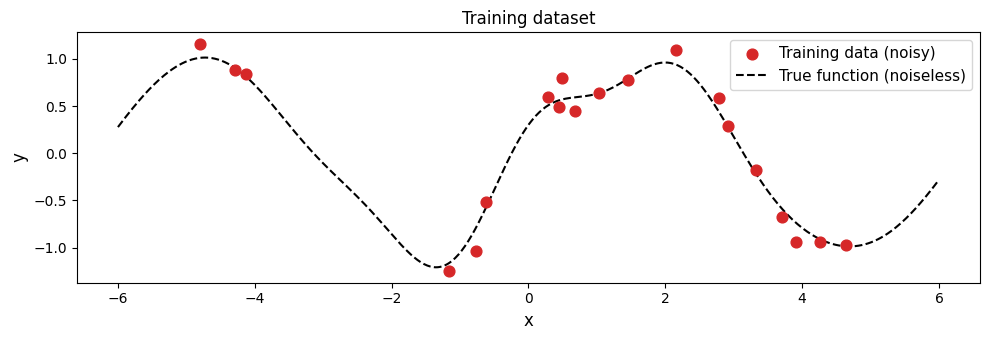

In [2]:
np.random.seed(0)
n_train  = 20
X        = np.sort(np.random.uniform(-5, 5, n_train))
y        = np.sin(X) + 0.3 * np.cos(2.5 * X) * np.exp(-X**2 / 8) + 0.1 * np.random.randn(n_train)

X2d      = X.reshape(-1, 1)
X_plot   = np.linspace(-6, 6, 300)
Xplot2d  = X_plot.reshape(-1, 1)

x_fine   = np.linspace(-6, 6, 500)
y_true   = np.sin(x_fine) + 0.3 * np.cos(2.5 * x_fine) * np.exp(-x_fine**2 / 8)

plt.figure(figsize=(10, 3.5))
plt.scatter(X, y, c='#d62728', s=60, zorder=5, label='Training data (noisy)')
plt.plot(x_fine, y_true, 'k--', lw=1.5, label='True function (noiseless)')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(fontsize=11)
plt.title('Training dataset', fontsize=12)
plt.tight_layout()
plt.show()

## Shared Plot Helper

The function `plot_gp` below is used by every kernel section.
It fits a `GaussianProcessRegressor` with the given kernel, computes the posterior, and renders the two-panel figure.

In [3]:
# Covariance evaluation grid (shared across all kernels)
_Xcov = np.linspace(-6, 6, 60).reshape(-1, 1)


def plot_gp(kernel, title, alpha_noise=1e-3):
    """
    Fit a GP (optimizer disabled) and render:
      Left  – posterior mean +/- 2sigma confidence band
      Right – prior covariance heatmap K(X_plot, X_plot)
    """
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha_noise,
        optimizer=None,
        normalize_y=True
    )
    gp.fit(X2d, y)
    y_mean, y_std = gp.predict(Xplot2d, return_std=True)
    lml = gp.log_marginal_likelihood_value_

    K = kernel(_Xcov)   # (60, 60) prior covariance

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: posterior ──────────────────────────────────────────────────────
    ax1.fill_between(X_plot, y_mean - 2 * y_std, y_mean + 2 * y_std,
                     color='silver', alpha=0.55, label='\u00b12\u03c3 confidence')
    ax1.plot(X_plot, y_mean, color='#1a1a2e', lw=2.0, label='Posterior mean')
    ax1.scatter(X, y, c='#d62728', s=55, zorder=5, label='Training data')
    ax1.set_xlim(X_plot[0], X_plot[-1])
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('y', fontsize=12)
    ax1.set_title(f'{title}\nlog p(y | X) = {lml:.2f}', fontsize=11)
    ax1.legend(fontsize=10)

    # ── Right: covariance heatmap ─────────────────────────────────────────────
    vmax = np.abs(K).max()
    im = ax2.imshow(K, origin='upper', cmap='viridis',
                    extent=[-6, 6, 6, -6], aspect='auto',
                    vmin=0, vmax=vmax)
    fig.colorbar(im, ax=ax2, shrink=0.85, label="k(x, x')")
    ax2.set_xlabel('x',  fontsize=12)
    ax2.set_ylabel("x'", fontsize=12)
    ax2.set_title('Prior covariance  K(X, X)', fontsize=11)

    plt.tight_layout()
    plt.show()

## 1. Squared Exponential / RBF Kernel

The **Radial Basis Function (RBF)** kernel, also called the *Squared Exponential*, is the most widely used GP kernel:

$$k_{\text{RBF}}(x,x') = \exp\!\left(-\frac{(x-x')^2}{2\ell^2}\right)$$

- **$\ell$** (length scale): governs how quickly correlations decay with distance. Small $\ell$ → rapidly varying, wiggly function; large $\ell$ → slowly varying, smooth function.
- All sample paths are **infinitely differentiable** ($C^\infty$).
- The covariance matrix has the characteristic "ridge" pattern: $K_{ij}$ depends only on the lag $|x_i - x_j|$ (stationary kernel).

**Slider:** move $\ell$ and observe how the width of the ridge in the covariance heatmap and the smoothness of the posterior change jointly.

In [4]:
def _rbf(length_scale):
    plot_gp(RBF(length_scale=length_scale),
            f'RBF  \u2113 = {length_scale:.3g}')

interact(_rbf,
    length_scale=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u2113',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='ℓ', layout=Layout(width=…

## 2. Matérn Kernel

The **Matérn** kernel generalises the RBF by introducing a roughness parameter $\nu$ that controls the **differentiability** of sample paths:

$$k_{\nu}(x,x') = \frac{2^{1-\nu}}{\Gamma(\nu)}\!\left(\frac{\sqrt{2\nu}\,|x-x'|}{\ell}\right)^\nu K_\nu\!\left(\frac{\sqrt{2\nu}\,|x-x'|}{\ell}\right)$$

where $K_\nu$ is the modified Bessel function of the second kind.

| $\nu$ | Differentiability | Special case |
|--------|-------------------|-------------|
| 0.5 | $C^0$ (continuous only) | $k(r) = e^{-r/\ell}$ — Ornstein-Uhlenbeck / exponential kernel |
| 1.5 | $C^1$ (once differentiable) | $k(r) = (1 + \frac{\sqrt{3}r}{\ell})e^{-\sqrt{3}r/\ell}$ |
| 2.5 | $C^2$ (twice differentiable) | Heavier tails than RBF; good default for physical processes |

As $\nu \to \infty$ the Matérn converges to the RBF kernel.

**Sliders:** compare $\nu$ values to see how roughness affects the jaggedness of the posterior mean and the shape of the covariance ridges.

In [5]:
def _matern(length_scale, nu):
    plot_gp(Matern(length_scale=length_scale, nu=nu),
            f'Mat\u00e9rn  \u2113 = {length_scale:.3g}  \u03bd = {nu}')

interact(_matern,
    length_scale=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u2113',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    nu=widgets.SelectionSlider(
        options=[('\u03bd = 0.5  (C\u2070, Ornstein-Uhlenbeck)', 0.5),
                 ('\u03bd = 1.5  (C\u00b9)', 1.5),
                 ('\u03bd = 2.5  (C\u00b2)', 2.5)],
        value=1.5,
        description='\u03bd',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='ℓ', layout=Layout(width=…

## 3. Rational Quadratic Kernel

The **Rational Quadratic (RQ)** kernel is equivalent to an **infinite mixture of RBF kernels** with different length scales, weighted by a Gamma distribution:

$$k_{\text{RQ}}(x,x') = \left(1 + \frac{(x-x')^2}{2\alpha\ell^2}\right)^{-\alpha}$$

- **$\ell$**: characteristic (modal) length scale.
- **$\alpha$** (scale-mixture parameter): relative contribution of short vs. long-range variations.
  - Small $\alpha$ → dominated by short length scales (wiggly).
  - Large $\alpha$: as $\alpha \to \infty$, $k_\text{RQ} \to k_\text{RBF}$.
- Sample paths are infinitely differentiable ($C^\infty$), but with heavier tails than the pure RBF.

**Sliders:** at large $\alpha$ the RQ and RBF posteriors should look nearly identical.

In [6]:
def _rq(length_scale, alpha):
    plot_gp(RationalQuadratic(length_scale=length_scale, alpha=alpha),
            f'RationalQuadratic  \u2113 = {length_scale:.3g}  \u03b1 = {alpha:.3g}')

interact(_rq,
    length_scale=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u2113',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    alpha=FloatLogSlider(
        value=1.0, base=10, min=-2, max=3, step=0.1,
        description='\u03b1',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='ℓ', layout=Layout(width=…

## 4. Exp-Sine-Squared (Periodic) Kernel

The **ExpSineSquared** kernel is designed for **strictly periodic** functions:

$$k_{\text{per}}(x,x') = \exp\!\left(-\frac{2\sin^2\!\big(\pi|x-x'|/p\big)}{\ell^2}\right)$$

- **$p$** (periodicity): the repeat period of the function.
- **$\ell$** (length scale): smoothness *within* each period — small $\ell$ → rough wiggles per cycle; large $\ell$ → near-constant within each period.
- The covariance heatmap shows a **regular block-diagonal / stripe pattern** reflecting the periodicity.
- Ideal for seasonal or cyclic signals; extrapolates periodically beyond the training range.

**Sliders:** set $p \approx 2\pi \approx 6.28$ to match the sinusoidal component of the training data.

In [ ]:
def _ess(length_scale, periodicity):
    plot_gp(ExpSineSquared(length_scale=length_scale, periodicity=periodicity),
            f'ExpSineSquared  \u2113 = {length_scale:.3g}  p = {periodicity:.2f}')

interact(_ess,
    length_scale=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u2113',
        style={'description_width': '50px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    periodicity=FloatSlider(
        value=6.28, min=0.5, max=12.0, step=0.25,
        description='period p',
        style={'description_width': '65px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.2f'
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='ℓ', layout=Layout(width=…

## 5. Dot Product Kernel

The **DotProduct** kernel is **non-stationary**: it depends on the absolute positions of $x$ and $x'$, not just their difference:

$$k_{\text{dp}}(x,x') = \sigma_0^2 + x\cdot x'$$

- **$\sigma_0$**: inhomogeneous bias (offset). When $\sigma_0=0$ the kernel is *homogeneous* (the GP mean must pass through the origin $x=0$); larger $\sigma_0$ relaxes this.
- This kernel is equivalent to Bayesian linear regression with a prior $\mathbf{w} \sim \mathcal{N}(0, I)$, $b \sim \mathcal{N}(0, \sigma_0^2)$.
- The covariance heatmap is **not constant along diagonals** — a visible asymmetry distinguishes it from all stationary kernels.
- Best for data with a clear global trend (linear or polynomial extrapolation).

> Because this kernel is non-stationary, confidence bands **grow** the further we extrapolate from the data.

In [8]:
def _dp(sigma_0):
    plot_gp(DotProduct(sigma_0=sigma_0),
            f'DotProduct  \u03c3\u2080 = {sigma_0:.3g}')

interact(_dp,
    sigma_0=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u03c3\u2080',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='σ₀', layout=Layout(width…

## 6. Composite: RBF + WhiteKernel

Kernels in scikit-learn support **addition** and **multiplication**. Adding a `WhiteKernel` explicitly models **i.i.d. Gaussian observation noise** with variance $\sigma_n^2$:

$$k(x,x') = \underbrace{e^{-(x-x')^2/(2\ell^2)}}_{\text{smooth latent function}} + \underbrace{\sigma_n^2\,\mathbf{1}[x=x']}_{\text{observation noise}}$$

This is the **standard formulation** for noisy GP regression. Compared to using the `alpha` parameter in `GaussianProcessRegressor` this approach makes the noise a learnable component of the kernel.

- The covariance heatmap shows the full prior including the diagonal noise spike.
- **Large $\sigma_n^2$**: the GP trusts the data less — wider confidence bands, smoother posterior.
- **Small $\sigma_n^2$**: the GP interpolates tightly through the data points.

> We set `alpha_noise=1e-6` (jitter only) since all observation noise is absorbed into `WhiteKernel`.

In [9]:
def _rbf_white(length_scale, noise_level):
    kernel = RBF(length_scale=length_scale) + WhiteKernel(noise_level=noise_level)
    plot_gp(kernel,
            f'RBF + White  \u2113 = {length_scale:.3g}  \u03c3\u00b2 = {noise_level:.3g}',
            alpha_noise=1e-6)

interact(_rbf_white,
    length_scale=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u2113',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    noise_level=FloatLogSlider(
        value=0.01, base=10, min=-4, max=1, step=0.1,
        description='\u03c3\u00b2',
        style={'description_width': '40px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='ℓ', layout=Layout(width=…

## 7. Composite: ConstantKernel × RBF + WhiteKernel

Multiplying a kernel by a `ConstantKernel` adds a learnable **signal amplitude** $\sigma_f^2$:

$$k(x,x') = \sigma_f^2 \cdot e^{-(x-x')^2/(2\ell^2)} + \sigma_n^2\,\mathbf{1}[x=x']$$

This separates the three physically meaningful degrees of freedom:

| Parameter | Symbol | Controls |
|-----------|--------|----------|
| `constant_value` | $\sigma_f^2$ | **Signal variance** — overall amplitude of the unknown function |
| `length_scale` | $\ell$ | **Frequency content** — how fast the function varies |
| `noise_level` | $\sigma_n^2$ | **Noise variance** — scatter around the latent function |

Without the `ConstantKernel`, the RBF has an implicit unit signal variance ($\sigma_f^2 = 1$). When `normalize_y=True` is set in the GP, the target values are normalised so this matters less — but in general it is good practice to include it for interpretability.

In [10]:
def _const_rbf_white(signal_var, length_scale, noise_level):
    kernel = (ConstantKernel(constant_value=signal_var)
              * RBF(length_scale=length_scale)
              + WhiteKernel(noise_level=noise_level))
    plot_gp(kernel,
            f'C\u00b7RBF + White  \u03c3\u00b2_f={signal_var:.3g}  \u2113={length_scale:.3g}  \u03c3\u00b2_n={noise_level:.3g}',
            alpha_noise=1e-6)

interact(_const_rbf_white,
    signal_var=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u03c3\u00b2_f',
        style={'description_width': '50px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    length_scale=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u2113',
        style={'description_width': '50px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    noise_level=FloatLogSlider(
        value=0.01, base=10, min=-4, max=1, step=0.1,
        description='\u03c3\u00b2_n',
        style={'description_width': '50px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='σ²_f', layout=Layout(wid…

## 8. Composite: ExpSineSquared × RBF + WhiteKernel

For signals with **periodicity that decays with distance**, we multiply the periodic kernel by a stationary envelope:

$$k(x,x') = k_{\text{per}}(x,x')\cdot k_{\text{RBF}}(x,x') + \sigma_n^2\,\mathbf{1}[x=x']$$

- **$\ell_{\text{per}}$**: smoothness within each period.
- **$p$**: period length.
- **$\ell_{\text{env}}$**: length scale of the decaying RBF envelope — determines how far away the periodicity is felt.
- **$\sigma_n^2$**: observation noise.

This is a common model for **quasi-periodic** signals such as sunspot activity, seasonal weather, or EEG rhythms.

In [11]:
def _per_rbf_white(ls_per, period, ls_env, noise_level):
    kernel = (ExpSineSquared(length_scale=ls_per, periodicity=period)
              * RBF(length_scale=ls_env)
              + WhiteKernel(noise_level=noise_level))
    plot_gp(kernel,
            f'ExpSine\u00d7RBF+White  \u2113_per={ls_per:.2g}  p={period:.2f}  \u2113_env={ls_env:.2g}  \u03c3\u00b2={noise_level:.2g}',
            alpha_noise=1e-6)

interact(_per_rbf_white,
    ls_per=FloatLogSlider(
        value=1.0, base=10, min=-2, max=2, step=0.1,
        description='\u2113_per',
        style={'description_width': '55px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    period=FloatSlider(
        value=6.28, min=0.5, max=12.0, step=0.25,
        description='period p',
        style={'description_width': '65px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.2f'
    ),
    ls_env=FloatLogSlider(
        value=5.0, base=10, min=-1, max=2, step=0.1,
        description='\u2113_env',
        style={'description_width': '55px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    ),
    noise_level=FloatLogSlider(
        value=0.01, base=10, min=-4, max=1, step=0.1,
        description='\u03c3\u00b2',
        style={'description_width': '55px'},
        layout=widgets.Layout(width='480px'),
        continuous_update=False, readout_format='.3g'
    )
);

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='ℓ_per', layout=Layout(wi…